In [2]:
from obspy import read, UTCDateTime

In [4]:
st = read("../Data/0502_14_15_HL.mseed")

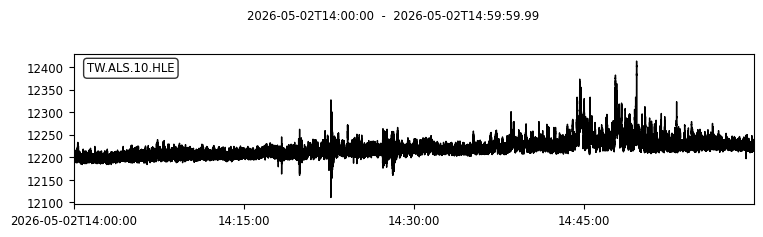

In [5]:
st[0].plot();

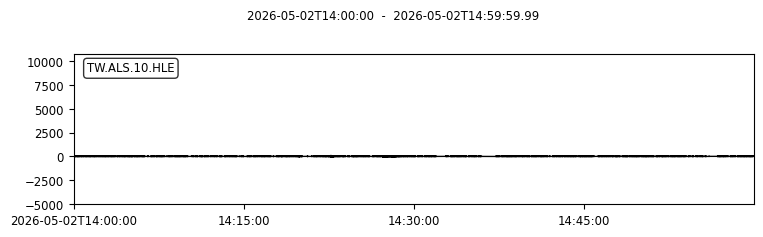

In [6]:
st_filter = st.filter("bandpass", freqmin=1.0, freqmax=20.0)
st_filter[0].plot();

In [14]:
station = ["CHK","ENA","SEB","LAY","EAS","SSD","SGL","ECS","SGS","STY","ELD","SCL","WDG","PNG","SML","ETM","HEN","NSK","SML","WTP","WSF","WDG","ALS","PNG"]

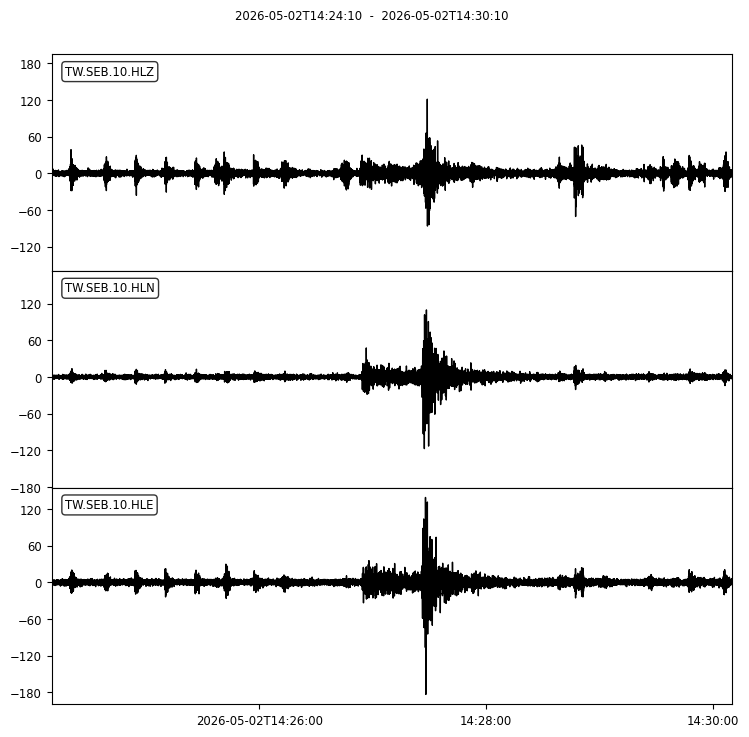

In [18]:
st_slice = st_filter.slice(starttime=UTCDateTime("2026-05-02T14:24:10"), endtime=UTCDateTime("2026-05-02T14:30:10"))
st_slice.select(station="SEB").plot();

In [1]:
### Gammam

正在掃描檔案資訊...
資料範圍: 2026-05-02T14:00:00.000000Z ~ 2026-05-02T14:59:59.990000Z
正在讀取拾取結果: ./seismic_plots/picks_results.csv
✅ 成功讀取 48 個拾取點
           id type                        timestamp      prob
0   TW.SGS.10    p 2026-05-02 14:22:36.120000+00:00  0.978308
1   TW.WTP.10    p 2026-05-02 14:22:36.520000+00:00  0.980203
2   TW.STY.10    p 2026-05-02 14:22:36.850000+00:00  0.976355
3   TW.SGS.10    s 2026-05-02 14:22:38.190000+00:00  0.939178
4   TW.WTP.10    s 2026-05-02 14:22:38.850000+00:00  0.953587
5   TW.STY.10    s 2026-05-02 14:22:39.300000+00:00  0.906709
6   TW.ALS.10    p 2026-05-02 14:22:41.950000+00:00  0.958331
7   TW.SSD.10    p 2026-05-02 14:22:42.120000+00:00  0.958888
8   TW.CHY.10    p 2026-05-02 14:22:42.650000+00:00  0.777856
9   TW.WSF.10    p 2026-05-02 14:22:45.340000+00:00  0.922818
10  TW.SSD.10    s 2026-05-02 14:22:48.440000+00:00  0.781912
11  TW.ALS.10    s 2026-05-02 14:22:48.680000+00:00  0.834207
12  TW.WNT.10    p 2026-05-02 14:22:48.650000+00:00  0.7759

Clustering (eps=20.83): 100%|██████████| 6/6 [00:00<00:00, 28630.06it/s]


Associating 48 picks with 1 CPUs
.....4 events detected by Gamma


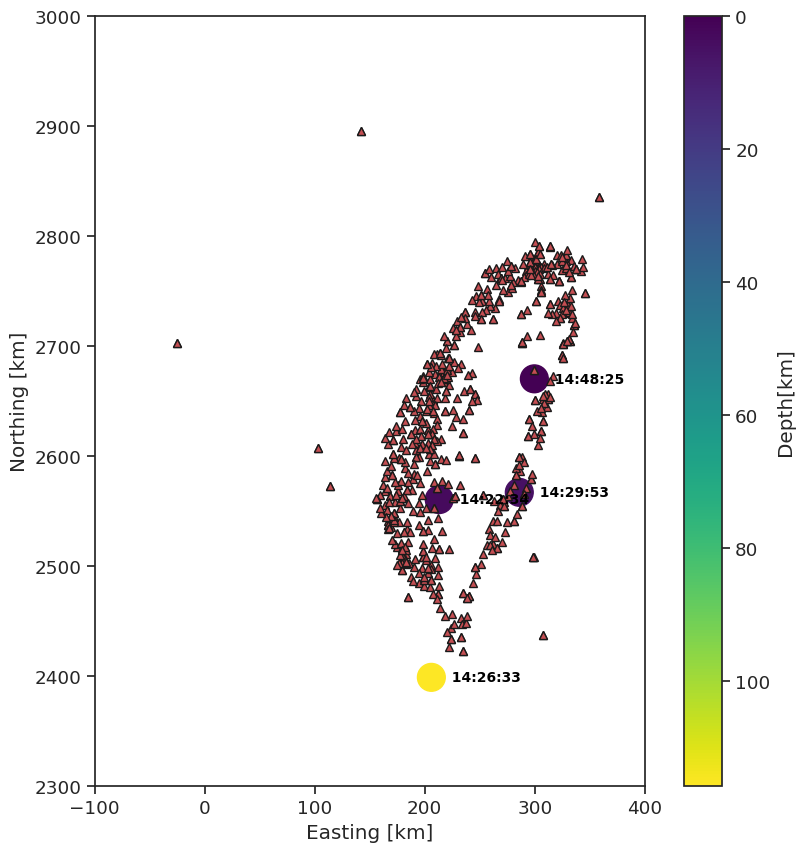

In [82]:
import os
import obspy
import json
from obspy.clients.fdsn import Client
from obspy import UTCDateTime, read
from pyproj import CRS, Transformer
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from gamma.utils import association
import seisbench.models as sbm

sns.set(font_scale=1.2)
sns.set_style("ticks")

# --- 1. 參數設定 ---
MSEED_PATH = "../Data/0502_14_15_HL.mseed"
OUTPUT_DIR = "seismic_plots"
CHUNK_LENGTH = 900  # 每次讀取 30 分鐘 (避免記憶體溢位)
# CHUNK_LENGTH = 60    # 每次讀取 1 分鐘 (單一事件)
OVERLAP = 60         # 時段間重疊 1 分鐘 (確保地震不被切斷)
STRIDE = 500         # 模型滑動步長 (500 samples = 5秒，重疊越高越準)
MODEL_TYPE = "stead" # 使用 EQTransformer

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Gamma 參數設定 ---
# Projections
wgs84 = CRS.from_epsg(4326)
local_crs = CRS.from_epsg(3826)  # SIRGAS-Chile 2016 / UTM zone 19S
transformer = Transformer.from_crs(wgs84, local_crs)

# Gamma
config = {}
config["dims"] = ["x(km)", "y(km)", "z(km)"]
config["use_dbscan"] = True
config["use_amplitude"] = False
config["x(km)"] = (100, 400)
config["y(km)"] = (2400, 2800)
config["z(km)"] = (0, 150)
config["vel"] = {
    "p": 5.8,
    "s": 2.5,
}  # We assume rather high velocities as we expect deeper events
config["method"] = "BGMM"
if config["method"] == "BGMM":
    config["oversample_factor"] = 4
if config["method"] == "GMM":
    config["oversample_factor"] = 1

# DBSCAN
config["bfgs_bounds"] = (
    (config["x(km)"][0] - 1, config["x(km)"][1] + 1),  # x
    (config["y(km)"][0] - 1, config["y(km)"][1] + 1),  # y
    (0, config["z(km)"][1] + 1),  # x
    (None, None),  # t
)
config["dbscan_eps"] = 25  # seconds
config["dbscan_min_samples"] = 3

# Filtering
config["min_picks_per_eq"] = 5
config["max_sigma11"] = 2.0
config["max_sigma22"] = 1.0
config["max_sigma12"] = 1.0

# --- 3. 獲取時間範圍 ---
print("正在掃描檔案資訊...")
st_header = read(MSEED_PATH, headonly=True)
global_start = min(tr.stats.starttime for tr in st_header)
global_end = max(tr.stats.endtime for tr in st_header)
print(f"資料範圍: {global_start} ~ {global_end}")

# --- 4. 滑動視窗處理流程 ---
PICK_FILE = "./seismic_plots/picks_results.csv"
if os.path.exists(PICK_FILE):
    print(f"正在讀取拾取結果: {PICK_FILE}")

    # 讀取 CSV
    raw_pick_df = pd.read_csv(PICK_FILE)
    
    # 轉換格式以符合 GaMMA 需求
    # GaMMA 必備欄位: id, type, time, prob
    pick_df = pd.DataFrame({
        "id": raw_pick_df["station"],
        "type": raw_pick_df["phase"].str.lower(),   # 轉成小寫 p, s
        "timestamp": pd.to_datetime(raw_pick_df["peak_time"]), # 轉成 datetime 物件
        "prob": raw_pick_df["peak_value"]
    })
    
    # 去除重複項 (避免同一個點位被存入多次)
    pick_df = pick_df.drop_duplicates(subset=["id", "timestamp", "type"])
    
    print(f"✅ 成功讀取 {len(pick_df)} 個拾取點")
else:
    print(f"❌ 找不到檔案 {PICK_FILE}，請確認路徑。")
    pick_df = pd.DataFrame()

# 迴圈結束後再轉為pandas DataFrame，避免每次迴圈都轉換造成效能問題
pick_df = pd.DataFrame(pick_df)
print(pick_df)

with open('stations.json', 'r', encoding='utf-8') as f:
    stations_data = json.load(f)

station_df_list = []
for station_name, info in stations_data.items():
    # 根據範例：coords[0]=Lat, coords[1]=Lon, coords[2]=Elv
    station_df_list.append({
        "id": f"{info['network']}.{station_name}.10",
        "longitude": info['coords'][1],  
        "latitude": info['coords'][0],   
        "elevation(m)": info['coords'][2],
    })

station_df = pd.DataFrame(station_df_list)
station_df["x(km)"] = station_df.apply(
    lambda x: transformer.transform(x["latitude"], x["longitude"])[0] / 1e3, axis=1
)
station_df["y(km)"] = station_df.apply(
    lambda x: transformer.transform(x["latitude"], x["longitude"])[1] / 1e3, axis=1
)
station_df["z(km)"] = -station_df["elevation(m)"] / 1e3

northing = {station: y for station, y in zip(station_df["id"], station_df["y(km)"])}
station_dict = {
    station: (x, y)
    for station, x, y in zip(station_df["id"], station_df["x(km)"], station_df["y(km)"])
    }

# Gamma 關聯分析
catalogs, assignments = association(pick_df, station_df, config, method=config["method"])
catalog = pd.DataFrame(catalogs)
assignments = pd.DataFrame(assignments, columns=["pick_idx", "event_idx", "prob_gamma"])


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.set_aspect("equal")

# 先畫測站
ax.plot(station_df["x(km)"], station_df["y(km)"], "r^", mew=1, mec="k")

# 再畫震央
cb = ax.scatter(catalog["x(km)"], catalog["y(km)"], c=catalog["z(km)"], s=400, cmap="viridis")
print(len(catalog), "events detected by Gamma")
cbar = fig.colorbar(cb)
cbar.ax.set_ylim(cbar.ax.get_ylim()[::-1])
cbar.set_label("Depth[km]")
for x, y, t in zip(catalog["x(km)"], catalog["y(km)"], catalog["time"]):
        # 格式化時間：將 '2026-05-02T14:22:34.185' 轉換為 '14:22:34' 
        # 如果 time 是字串，取 [11:19]；如果是 datetime 物件，用 strftime
        t_label = t.strftime('%H:%M:%S') if hasattr(t, 'strftime') else str(t)[11:19]
        
        ax.text(
            x+10, y, 
            f"  {t_label}", # 前面加空格讓標籤與點位錯開
            fontsize=10, 
            ha="left",      # 水平對齊：靠左 (標籤在點的右邊)
            va="center",    # 垂直對齊：置中
            color="black", 
            weight="bold",
            zorder=4        # 確保標籤在最上層
        )
    

ax.set_xlabel("Easting [km]")
ax.set_ylabel("Northing [km]")
ax.set_xlim(-100, 400)
ax.set_ylim(2300, 3000)
plt.show()
# plt.savefig("Gamma_Association_Result.png", bbox_inches="tight")
plt.close(fig)

In [ ]:
# --- 5. 輸出分析報告與詳細編目 ---

# A. 座標回推 (公里 -> 經緯度)
# Transformer 預期 (x, y) 單位通常是公尺，故需 * 1e3
if not catalog.empty:
    catalog["latitude"], catalog["longitude"] = transformer.transform(
        catalog["x(km)"] * 1e3, catalog["y(km)"] * 1e3, direction="INVERSE"
    )

# B. 整合資訊與判定類別
# 我們利用 assignments 來計算每個 event_idx 實際關聯到的站數
event_station_counts = assignments.groupby("event_idx")["pick_idx"].count()
catalog["total_picks"] = catalog["event_index"].map(event_station_counts)

def get_note(n):
    if n >= 5: return f"Earthquake (Total {n} picks)"
    elif 3 <= n < 5: return f"Suspected (Total {n} picks)"
    else: return f"Noise/Isolated (Total {n} picks)"

catalog["note"] = catalog["total_picks"].apply(get_note)

# C. 篩選與格式化輸出
# 為了符合你的格式，我們從 pick_df 中找回每個事件「第一個觸發的站點」作為代表
event_details = []
for _, row in catalog.iterrows():
    # 找到屬於該事件的所有 picks
    event_picks_indices = assignments[assignments["event_idx"] == row["event_index"]]["pick_idx"]
    event_picks = pick_df.iloc[event_picks_indices]
    first_pick = event_picks.sort_values("timestamp").iloc[0] # 取最早觸發的站

    event_details.append({
        "station": first_pick["id"],
        "start_time_str": row["time"],
        "lat": round(row["latitude"], 4),
        "lon": round(row["longitude"], 4),
        "depth_km": round(row["z(km)"], 2),
        "gamma_score": round(row["gamma_score"], 2),
        "sigma_time": round(row["sigma_time"], 3),
        "event_id": int(row["event_index"]),
        "total_picks": int(row["total_picks"]),
        "note": row["note"]
    })

detail_df = pd.DataFrame(event_details)

# D. 儲存檔案
output_csv = os.path.join(OUTPUT_DIR, "associated_catalog_with_notes_G.csv")
OUTPUT_REPORT = os.path.join(OUTPUT_DIR, "association_report_G.txt")
detail_df.to_csv(output_csv, index=False)

# 1. 篩選資料
confirmed = detail_df[detail_df["total_picks"] >= 5]
suspected = detail_df[(detail_df["total_picks"] >= 3) & (detail_df["total_picks"] < 5)]

# 2. 定義要顯示的欄位
cols = ["station", "start_time_str", "lat", "lon", "depth_km", "gamma_score", "event_id", "note"]

# 3. 組合報告內容
report_lines = [
    "\n分析完成！",
    "-" * 40,
    f"原始觸發總數：{len(pick_df)} 筆",
    f"【確定】地震事件數 (>=5 站)：{len(confirmed)} 個",
    f"【疑似】地震事件數 (3-4 站)：{len(suspected)} 個",
    f"完整原始編目儲存至：{output_csv}",
    
    "\n--- 地震事件列表 (>=5 站) ---",
    confirmed[cols].to_string(index=False) if not confirmed.empty else "（無符合事件）",
    
    "\n--- 疑似地震列表 (3-4 站) ---",
    suspected[cols].to_string(index=False) if not suspected.empty else "（無符合事件）"
]

# 4. 合併並一次性輸出
full_report_text = "\n".join(report_lines)
print(full_report_text)

# (選配) 如果想把這份純文字報告也存檔：
with open(os.path.join(OUTPUT_DIR, "summary_report.txt"), "w", encoding="utf-8") as f:
    f.write(full_report_text)

with open(OUTPUT_REPORT, "w", encoding="utf-8") as f:
    f.write(full_report_text)

print(f"\n[系統通知] 統計報告已同步儲存至：{OUTPUT_REPORT}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3152411512.py, line 54)